In [1]:
from dlfs.base import Module, Loss, Optimizer

from dlfs.modules import SequentialWrapper
from dlfs.layers import DenseLayer
from dlfs.activation import ReLU, Sigmoid

from dlfs.loss import MSE_Loss, BCE_Loss
from dlfs.optimizers import Optimizer_Adam

from dlfs.helpers import DLFSData

import numpy as np
import matplotlib.pyplot as plt

In [2]:
class VAE(Module):

    def __init__(self, encoder: Module, decoder: Module, 
                       mu: Module, logvar: Module, 
                       loss_function: Loss = None, optimizer: Optimizer = None):
        """
        Variational Autoencoder generative model.

        Parameters
        ----------
        encoder: Module
            Encoder part of VAE.

        decoder: Module
            Decoder part of VAE.

        mu: Module
            Feed-forward network for predicting mean of distribution.

        logvar: Module
            Feed-forward network for predicting log variance of distribution.
        
        loss_function : Loss, default=None
            Loss function.
        
        optimizer : Optimizer, default=None
            Optimizer algorithm.
        """
        self.encoder = encoder
        self.decoder = decoder
        self.mu = mu
        self.logvar = logvar
        self.loss_function = loss_function
        self.optimizer = optimizer

    def _reparametrize(self, mu: np.ndarray, logvar: np.ndarray) -> None:
        """
        Helper method for the reparametrization trick. Creates latent variable attribute.

        Parameters
        ----------
        mu : np.ndarray
            Mean used to calculate latent variable.

        logvar : np.ndarray
            Log variance used to calculate latent variable.

        Returns
        -------
        None
        """
        self.std = np.exp(0.5 * logvar)
        self.eps = np.random.randn(*self.std.shape)  # random noise
        self.z = mu + self.eps * self.std

    def _reparametrize_backward(self, decoder_dinputs: np.ndarray, grad_kl_mu: np.ndarray, grad_kl_logvar: np.ndarray) -> None:
        """
        Helper method for the backpropagation of reparametrization trick. Creates mu and logvar gradient attributes.

        Parameters
        ----------
        decoder_dinputs : np.ndarray
            Decoder upstream gradient.

        grad_kl_mu : np.ndarray
            Mean upstream gradient from KL loss.

        grad_kl_logvar : np.ndarray
            Log variance upstream gradient from KL loss.

        Returns
        -------
        None
        """
        self.dmu = decoder_dinputs * 1 + grad_kl_mu
        self.dlogvar = decoder_dinputs * (0.5 * self.eps * self.std) + grad_kl_logvar

    def forward(self, x: np.ndarray, training: bool = False) -> None:
        """
        Forward pass for the Variational Autoencoder model. Creates output attribute.

        Parameters
        ----------
        x : np.ndarray
            Input array.

        training : bool, default=False
            A flag indicating whether the model is in training mode (`True`) or inference mode (`False`).
            This controls dropout, which is only applied during training.

        Returns
        -------
        None
        """

        # Pass data through encoder
        self.encoder.forward(x, training=training)

        # Compute distribution parameters from encoder output
        self.mu.forward(self.encoder.output, training=training)
        self.logvar.forward(self.encoder.output, training=training)

        # Using distribution parameters apply the reparametrization
        self._reparametrize(self.mu.output, self.logvar.output)

        # Pass sampled latent variable from reparametrization through decoder 
        self.decoder.forward(self.z, training=training)

        # Network output is the decoder output
        self.output = self.decoder.output

    def backward(self, y_true: np.ndarray, kl_beta: float) -> None:
        """
        Backward pass for the Variational Autoencoder model.

        Parameters
        ----------
        y_true : np.ndarray
            Original inputs used to compute the loss function gradient.

        kl_beta : float
            Coefficient used to scale the KL divergence loss and gradients during the KL warmup phase.

        Returns
        -------
        None
        """

        # Compute loss function grads
        self.loss_function.backward(self.output, y_true, self.mu.output, self.logvar.output, kl_beta)
        recon_grad, mu_grad, logvar_grad = self.loss_function.recon_loss.dinputs, self.loss_function.dmu, self.loss_function.dlogvar

        # Backprop reconstruction loss grad through decoder
        self.decoder.backward(recon_grad)

        # Backprop decoder grad, loss function grads with respect to mu and logvar through reparametrize
        self._reparametrize_backward(self.decoder.dinputs, mu_grad, logvar_grad)

        # Backprop distribution grads through their respective ffwd nets
        self.mu.backward(self.dmu)
        self.logvar.backward(self.dlogvar)

        # Add up the distribution parameter grads for encoder
        total_enc_grad = self.mu.dinputs + self.logvar.dinputs

        # Backprop through encoder
        self.encoder.backward(total_enc_grad)

    def train(self, X: np.ndarray, epochs: int = 1000, batch_size: int = None, print_every: int = None, kl_warmup_steps: int = 0) -> None:
        """
        Train the VAE model for a specified number of epochs, updating parameters using backpropagation.

        Parameters
        ----------
        X : np.ndarray
            Input and ground truth output data for the model.

        epochs : int, default=1000
            The number of epochs to train the model.

        batch_size : int, default=None
            The size of the batch to use for each training step. If `None`, the entire dataset is used
            for each forward/backward pass.

        print_every : int, default=None
            If provided, will print the current loss value every 
            `print_every` epochs.

        kl_warmup_steps : int, default=0
            Number of training epochs to apply the KL divergence downscaling. 
            This is done in order for the model to learn to reconstruct data before regularizing the latent space.

        Returns
        -------
        None
        """

        # Store recon and kl losses separately
        self.rec_loss = []
        self.kl_loss = []

        for i in range(epochs + 1):

            if kl_warmup_steps and kl_warmup_steps > 0:
                # Linear kl_beta during warmup
                self.kl_beta = min(1.0, (i + 1) / float(kl_warmup_steps))
            else:
                self.kl_beta = 1.0

            if batch_size is None:

                # Forward pass
                self.forward(X, training=True)

                # Backward pass
                self.backward(X, self.kl_beta)

                # Update parameters
                self.optimizer.pre_update_parameters()
                self.optimizer.update_parameters(self)
                self.optimizer.post_update_parameters()

                # Caluculate and record losses
                rec_l, kl_l, loss = self.loss_function.calculate(self.output, X, self.mu.output, self.logvar.output, self.kl_beta)
                self.rec_loss.append(rec_l)
                self.kl_loss.append(kl_l)

                if print_every is not None:
                    if not i % print_every:
                        print(f'===== EPOCH : {i} ===== LOSS : {loss:.5f} (Recon: {rec_l:.5f} | KL: {kl_l:.5f})')

            else:

                batch_loss = 0
                rec_loss = 0
                kl_loss = 0
                num_batches = 0

                for j in range(0, len(X), batch_size):

                    # Subset data into a batch
                    batch_X = X[j:j+batch_size, :]

                    # Forward pass
                    self.forward(batch_X)

                    # Calculate current batch loss
                    rec, kl, loss = self.loss_function.calculate(self.output, batch_X, self.mu.output, self.logvar.output)

                    batch_loss += loss
                    rec_loss += rec
                    kl_loss += kl
                    num_batches += 1

                    # Backward pass
                    self.backward(batch_X, self.kl_beta)

                    # Update parameters
                    self.optimizer.pre_update_parameters()
                    self.optimizer.update_parameters(self)
                    self.optimizer.post_update_parameters()

                # Record average batch losses
                avg_batch_loss = batch_loss / num_batches
                avg_rec_loss = rec_loss / num_batches
                avg_kl_loss = kl_loss / num_batches

                self.rec_loss.append(avg_rec_loss)
                self.kl_loss.append(avg_kl_loss)

                if print_every is not None:
                    if not i % print_every:
                        print(f'===== EPOCH : {i} ===== LOSS : {avg_batch_loss:.5f} (Recon: {avg_rec_loss:.5f} | KL: {avg_kl_loss:.5f}) =====')


# Loss function (reconstruction loss + KL divergence loss)

In [3]:
class VAE_Loss(Loss):

    def __init__(self, recon_loss: Loss) -> None:
        """
        Variational Autoencoder loss function consisting of reconstruction loss and KL divergence loss.

        Parameters
        ----------
        recon_loss : Loss
            Loss function used to learn reconstruction of data.
        """
        self.recon_loss = recon_loss()

    def calculate(self, y_pred: np.ndarray, y_true: np.ndarray, mu: np.ndarray, logvar: np.ndarray, kl_beta: float = 1.0) -> tuple[float, float, float]:
        """
        Calculate Variational Autoencoder loss.

        Parameters
        ----------
        y_pred : np.ndarray
            Predicted values.

        y_true : np.ndarray
            True values.

        mu : np.ndarray
            Mean of the latent space distribution.

        logvar : np.ndarray
            Log variance of the latent space distribution.

        kl_beta : float, default=1.0
            Scaling term of the KL divergence loss. Used during KL warmup in training.

        Returns
        -------
        rec_loss, kl_loss, total_loss : tuple[float, float, float]
            Separate recon, KL, and cumulative loss.
        """

        # Calculate recon loss
        recon_loss = self.recon_loss.calculate(y_pred, y_true)

        # Calculate KL divergence loss
        kl_loss = -0.5* np.mean(np.sum(1 + logvar - mu**2 - np.exp(logvar), axis=1))

        # Add up two losses
        total_loss = recon_loss + kl_beta * kl_loss

        return recon_loss, kl_beta * kl_loss, total_loss

    def backward(self, y_pred, y_true, mu, logvar, kl_beta=1.0) -> None:
        """
        Backward pass using Variational Autoencoder loss. Creates gradient attributes with respect to mean and log variance.

        Parameters
        ----------
        y_pred : np.ndarray
            Predicted values.

        y_true : np.ndarray
            True values.

        mu : np.ndarray
            Mean of the latent space distribution.

        logvar : np.ndarray
            Log variance of the latent space distribution.

        kl_beta : float, default=1.0
            Scaling term of the KL divergence loss. Used during KL warmup in training.

        Returns
        -------
        None
        """

        # Calculate recon loss gradient
        self.recon_loss.backward(y_pred, y_true)

        # Calculate KL divergence gradients
        dmu = mu
        dlogvar = -0.5 * (1 - np.exp(logvar))

        # Scale KL divergence gradients by kl_beta
        self.dmu = kl_beta * dmu
        self.dlogvar = kl_beta * dlogvar

# Load data

In [4]:
mnist_path = "data/mnist"

X_train, y_train, X_test, y_test = DLFSData.load_MNIST(mnist_path)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

X_train: (60000, 28, 28), y_train: (60000,)
X_test: (10000, 28, 28), y_test: (10000,)


In [5]:
# Selecting images of 3s and 7s
X_train, _ = DLFSData.select_MNIST_labels(X_train, y_train, labels=[0, 1, 3], limit=333, shuffle=False)
X_train = DLFSData.normalize_MNIST(X_train, range=(0, 1))

X_train = X_train.reshape(-1, 28*28)
print(f'X_train: {X_train.shape}')

X_train: (999, 784)


# Defining network components

In [6]:
input_dim = 784
hidden_dim = 256
latent_dim = 2

# Encoder feedforward
enc = SequentialWrapper(
    [DenseLayer(input_dim, hidden_dim),
     ReLU(),
     DenseLayer(hidden_dim, hidden_dim),
     ReLU(),
     DenseLayer(hidden_dim, hidden_dim),
     ReLU()]
)

# Mean feedforward
mu = SequentialWrapper(
    [DenseLayer(hidden_dim, hidden_dim),
     ReLU(),
     DenseLayer(hidden_dim, latent_dim),
     ReLU()]
)

# Log variance feedforward
logvar = SequentialWrapper(
    [DenseLayer(hidden_dim, hidden_dim),
     ReLU(),
     DenseLayer(hidden_dim, latent_dim),
     ReLU()]
)

# Decoder feedforward
dec = SequentialWrapper(
    [DenseLayer(latent_dim, hidden_dim),
     ReLU(),
     DenseLayer(hidden_dim, hidden_dim),
     ReLU(),
     DenseLayer(hidden_dim, input_dim),
     Sigmoid()
     ]
)

# Model training

In [7]:
lr = 1e-3
epochs = 3000
batch_size = None

loss_fn = VAE_Loss(recon_loss=BCE_Loss)
optimizer = Optimizer_Adam(learning_rate=lr)

model = VAE(encoder=enc, 
            decoder=dec, 
            mu=mu, 
            logvar=logvar, 
            loss_function = loss_fn, 
            optimizer=optimizer)

model.train(X_train, epochs=epochs, batch_size=batch_size, print_every=600, kl_warmup_steps=600)

===== EPOCH : 0 ===== LOSS : 545.67654 (Recon: 545.67654 | KL: 0.00000)
===== EPOCH : 600 ===== LOSS : 170.80059 (Recon: 162.17752 | KL: 8.62307)
===== EPOCH : 1200 ===== LOSS : 169.50260 (Recon: 159.76572 | KL: 9.73689)
===== EPOCH : 1800 ===== LOSS : 169.24340 (Recon: 159.33038 | KL: 9.91301)
===== EPOCH : 2400 ===== LOSS : 168.39736 (Recon: 158.91528 | KL: 9.48208)
===== EPOCH : 3000 ===== LOSS : 169.12884 (Recon: 158.91898 | KL: 10.20986)


# Loss graph

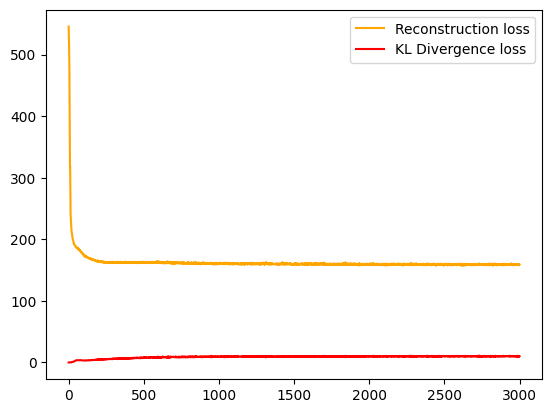

In [8]:
plt.plot(range(len(model.rec_loss)), model.rec_loss, color='orange', label='Reconstruction loss')
plt.plot(range(len(model.kl_loss)), model.kl_loss, color='red', label='KL Divergence loss')
plt.legend()
plt.show()

# Generating new images

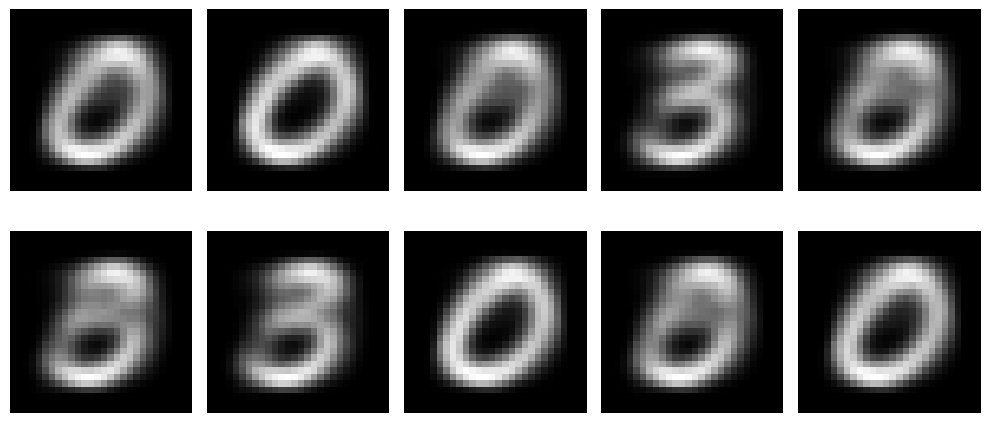

In [15]:
num_img = 10 

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten()

# Sample from random normal
Z = np.random.randn(num_img, latent_dim)

# Pass through decoder to reconstruct
model.decoder.forward(Z)

# Generate and plot n images
for i in range(num_img):
    img = model.decoder.output[i].reshape(28, 28)  # Reshape the output to 28x28 image
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [16]:
n_samples=100

img0 = X_train[0:n_samples].reshape(-1, 28, 28)

In [17]:
img1 = X_train[350:350+n_samples].reshape(-1, 28, 28)

In [18]:
img3 = X_train[-n_samples:].reshape(-1, 28, 28)

In [19]:
img0 = img0.reshape(-1, 28*28)
img1 = img1.reshape(-1, 28*28)
img3 = img3.reshape(-1, 28*28)

model.encoder.forward(img0, training=False)
model.mu.forward(model.encoder.output, training=False)
model.logvar.forward(model.encoder.output, training=False)

mu0, logvar0 = model.mu.output.mean(axis=0), np.exp(model.logvar.output).mean(axis=0)

print(mu0)
print(logvar0)

[0.         0.18908852]
[1. 1.]


In [20]:
model.encoder.forward(img1, training=False)
model.mu.forward(model.encoder.output, training=False)
model.logvar.forward(model.encoder.output, training=False)

mu1, logvar1 = model.mu.output.mean(axis=0), np.exp(model.logvar.output).mean(axis=0)

print(mu1)
print(logvar1)

[0.         7.25183562]
[1. 1.]


In [21]:
model.encoder.forward(img3, training=False)
model.mu.forward(model.encoder.output, training=False)
model.logvar.forward(model.encoder.output, training=False)

mu3, logvar3 = model.mu.output.mean(axis=0), np.exp(model.logvar.output).mean(axis=0)

print(mu3)
print(logvar3)

[0.         2.93017632]
[1. 1.]


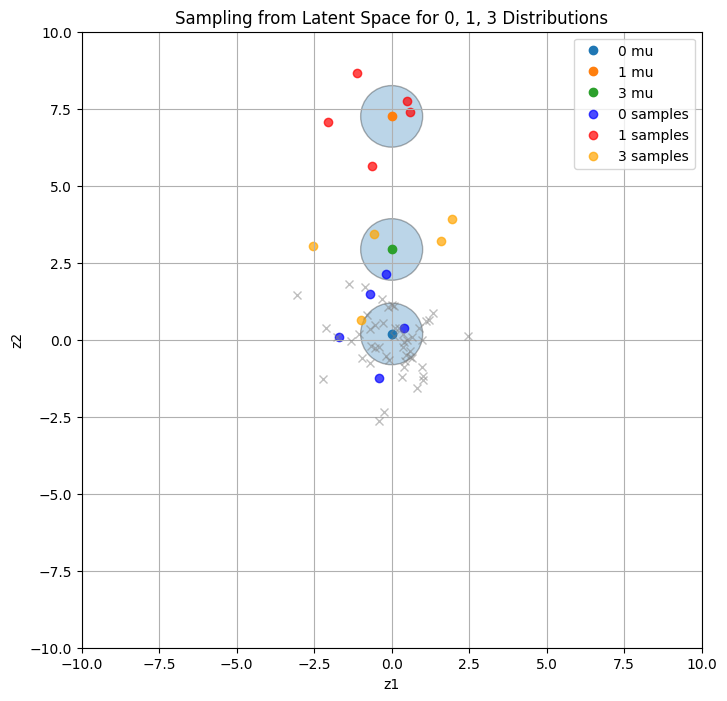

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Define the latent distributions for cat and dog (mean, variance)
latent_info = {
    "0": {"mu": mu0, "sigma": logvar0},
    "1": {"mu": mu1, "sigma": logvar1},
    "3": {"mu": mu3, "sigma": logvar3},
}

# Create plot
fig, ax = plt.subplots(figsize=(8, 8))

# Plot each Gaussian distribution for cat and dog
for label, info in latent_info.items():
    mu = info["mu"]
    sigma = info["sigma"]
    
    # Draw ellipse representing the 1-sigma boundary
    ellipse = Ellipse(mu, width=2 * sigma[0], height=2 * sigma[1],
                    edgecolor='black', alpha=0.3)
    ax.add_patch(ellipse)

    # Draw the mean point
    ax.plot(mu[0], mu[1], 'o', label=f'{label} mu')

# Optional: plot some random samples from the standard normal N(0, 1)
for _ in range(50):
    z = np.random.randn(2)  # standard Gaussian
    ax.plot(z[0], z[1], 'x', color='gray', alpha=0.5)

# Show sample points from the cat and dog latent distributions
c0_samples = np.random.normal(loc=latent_info['0']['mu'], scale=latent_info['0']['sigma'], size=(5, 2))
c1_samples = np.random.normal(loc=latent_info['1']['mu'], scale=latent_info['1']['sigma'], size=(5, 2))
c3_samples = np.random.normal(loc=latent_info['3']['mu'], scale=latent_info['3']['sigma'], size=(5, 2))

# Plot the samples
ax.scatter(c0_samples[:, 0], c0_samples[:, 1], c='blue', label="0 samples", alpha=0.7)
ax.scatter(c1_samples[:, 0], c1_samples[:, 1], c='red', label="1 samples", alpha=0.7)
ax.scatter(c3_samples[:, 0], c3_samples[:, 1], c='orange', label="3 samples", alpha=0.7)

# Labels and formatting
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_xlabel("z1")
ax.set_ylabel("z2")
ax.set_title("Sampling from Latent Space for 0, 1, 3 Distributions")
ax.grid(True)
ax.legend()
plt.show()


- probaj tsne, umap, pca za veci latent dim

- kovarijanca mu vektora i logvarova

- GMM